In [3]:
from sklearn.datasets import load_iris as iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics

# Load the iris dataset

iris = iris()
X = iris.data
y = iris.target


min_value = 0
max_value = 1

In [21]:
len(y)

150

## Feature Scaling

In [4]:
scaler = MinMaxScaler(feature_range=(min_value, max_value))
X_normalized = scaler.fit_transform(X)

## Train Test Splitting

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.8, random_state=42)

In [31]:
# 
print(f'{y_train}: {X_train}')

[1 0 1 1 0 1 2 2 0 1 2 2 0 2 0 1 2 2 1 2 1 1 2 2 0 1 2 0 1 2]: [[0.5        0.41666667 0.61016949 0.54166667]
 [0.05555556 0.125      0.05084746 0.08333333]
 [0.63888889 0.375      0.61016949 0.5       ]
 [0.33333333 0.25       0.57627119 0.45833333]
 [0.27777778 0.70833333 0.08474576 0.04166667]
 [0.36111111 0.41666667 0.52542373 0.5       ]
 [0.83333333 0.375      0.89830508 0.70833333]
 [0.66666667 0.54166667 0.79661017 0.83333333]
 [0.22222222 0.70833333 0.08474576 0.125     ]
 [0.16666667 0.16666667 0.38983051 0.375     ]
 [0.66666667 0.54166667 0.79661017 1.        ]
 [0.80555556 0.41666667 0.81355932 0.625     ]
 [0.16666667 0.66666667 0.06779661 0.        ]
 [0.66666667 0.45833333 0.77966102 0.95833333]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.72222222 0.45833333 0.66101695 0.58333333]
 [0.86111111 0.33333333 0.86440678 0.75      ]
 [0.55555556 0.375      0.77966102 0.70833333]
 [0.38888889 0.33333333 0.52542373 0.5       ]
 [0.61111111 0.41666667 0.76271186 0.7083333

## KNN Classifier

In [26]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

## Label Prediction

In [27]:
y_pred = knn.predict(X_test)

## Accuracy Test

In [33]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred, average='macro'))
print("Recall:", metrics.recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", metrics.f1_score(y_test, y_pred, average='macro'))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))


Accuracy: 0.9666666666666667
Precision: 0.9663504968383018
Recall: 0.9651372019793073
F1 Score: 0.9653153153153152
Confusion Matrix:
 [[43  0  0]
 [ 0 38  1]
 [ 0  3 35]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.93      0.97      0.95        39
           2       0.97      0.92      0.95        38

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



# Apple Quality

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
apples = pd.read_csv('/workspaces/Amrita_Lab/22AIE213/datasets/apple_quality.csv')
apples.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


# Feature One-Hot Encoding

In [18]:
#Replace the string values with numbers
apples['Quality'] = apples['Quality'].replace('bad', 0)
apples['Quality'] = apples['Quality'].replace('good', 1)
apples.head()

/tmp/ipykernel_29020/89991840.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  apples['Quality'] = apples['Quality'].replace('good', 1)


,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,1.0
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,1.0
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,0.0
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,1.0
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,1.0


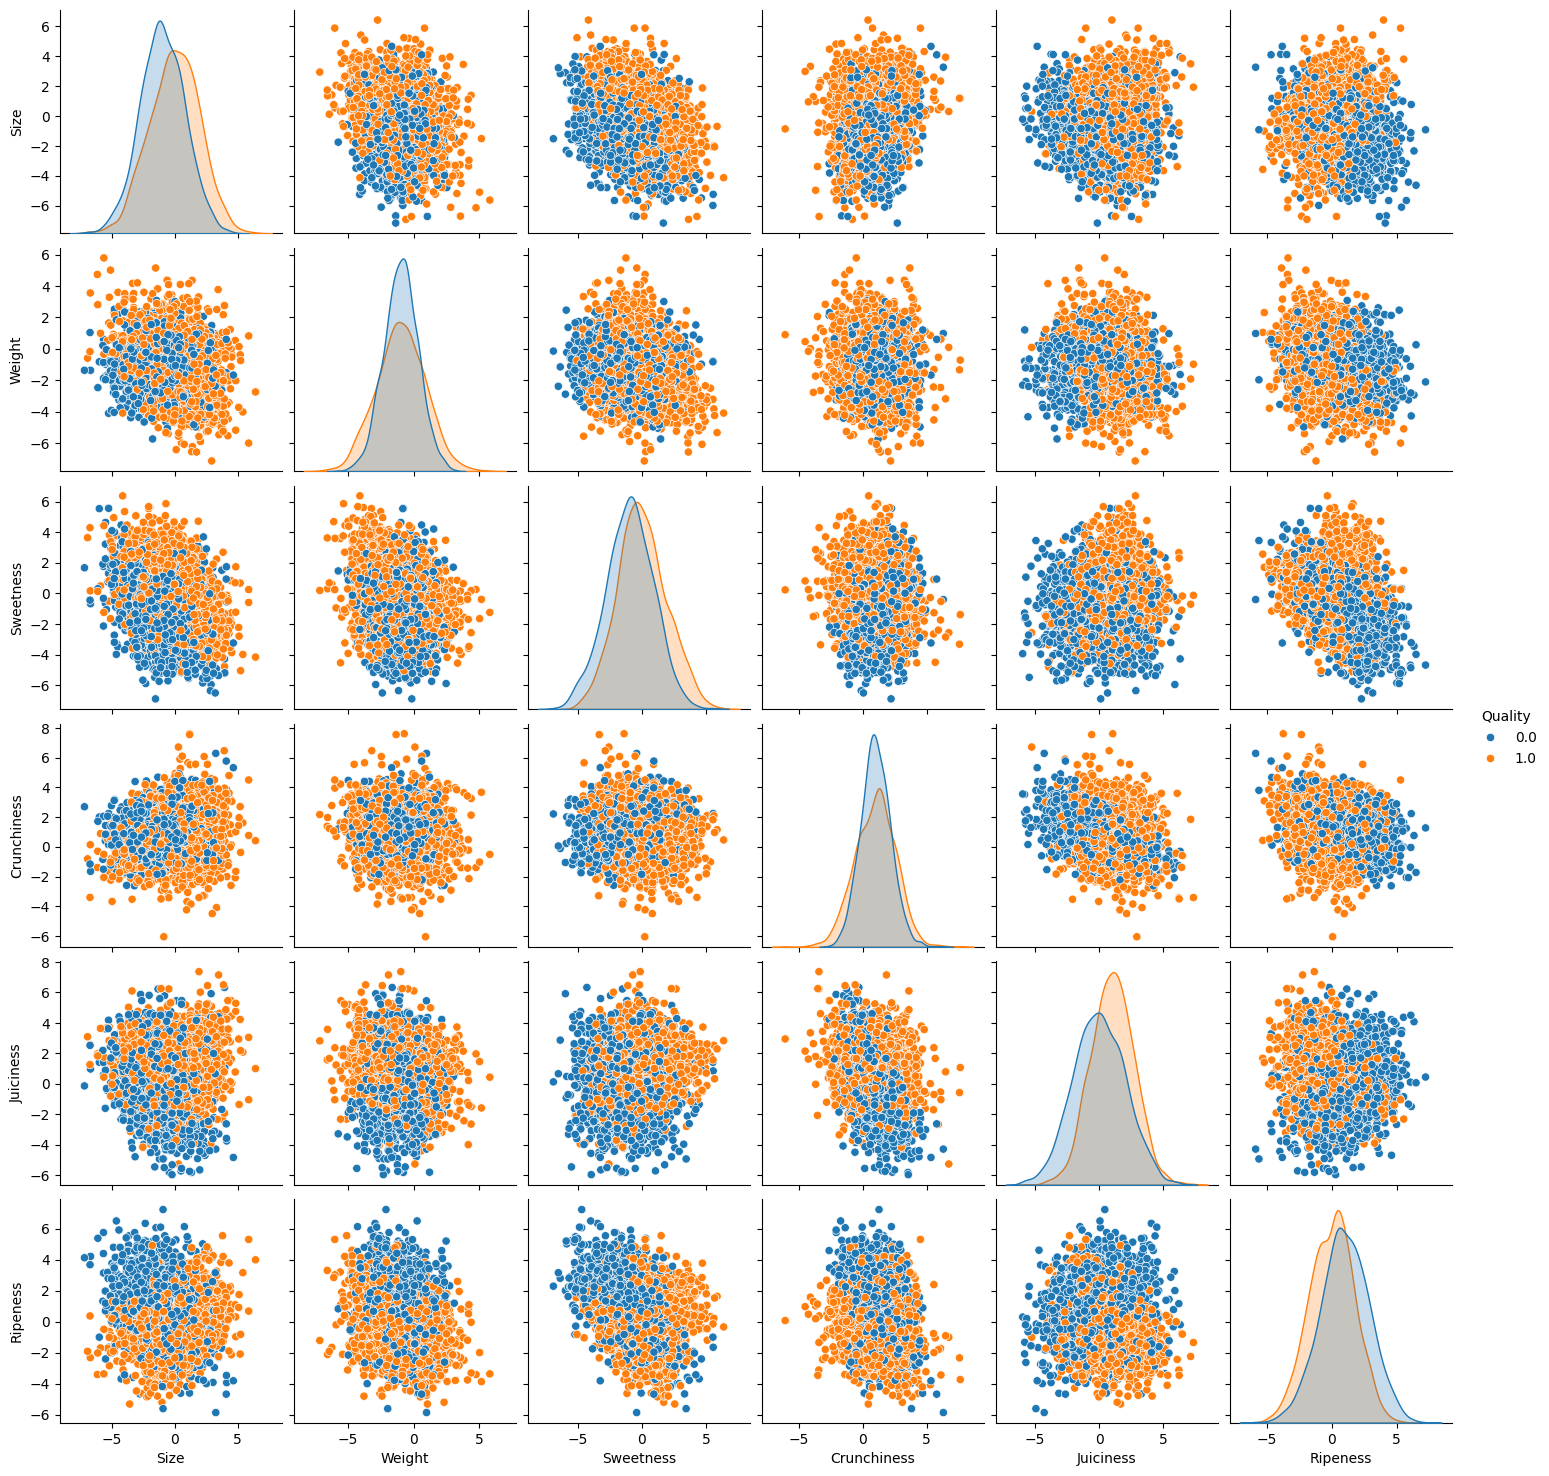

In [19]:
apples_plot = apples[['Size','Weight','Sweetness','Crunchiness','Juiciness','Ripeness','Acidity','Quality']]
sns.pairplot(apples_plot, hue='Quality')

In [9]:
from sklearn.model_selection import train_test_split
#Import decision tree classifier
from sklearn.tree import DecisionTreeClassifier
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics


In [22]:
#dataset cleaning
apples = apples.dropna()


In [31]:
# Find the appropriate features and labels
X = apples[['Size','Weight','Sweetness','Crunchiness','Juiciness','Ripeness','Acidity']]
y = apples[['Quality']]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=53)

# Create Decision Tree classifer object
clf = DecisionTreeClassifier()


In [ ]:
#Train DTC

clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)


In [35]:

# Model Accuracy, how often is the classifier correct?

print("Decision Tree Accuracy:",metrics.accuracy_score(y_test, y_pred))


Decision Tree Accuracy: 0.7858333333333334


# Two-Class Logistic Regression

In [39]:
# Two class logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create logistic regression object
logreg = LogisticRegression()

# Train the model using the training sets
logreg.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = logreg.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Logistic Regression Accuracy:",metrics.accuracy_score(y_test, y_pred))


Logistic Regression Accuracy: 0.7416666666666667


/home/codespace/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
